In [1]:
import os
os.getcwd()

'/content'

In [2]:
!ls

sample_data


In [ ]:
os.chdir("/Users/samswitz/GitHub/mech-int")

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import pandas as pd
import matplotlib.pyplot as plt
import tqdm

In [3]:
os.getcwd()

'/Users/samswitz/GitHub/mech-int'

In [15]:
!python scripts/batch_ablate.py \
  --checkpoint saved_models/sae_model_4x.pt \
  --eval-texts-path notebooks/eval_texts.txt \
  --output runs/ablation/small-run-1.csv

`torch_dtype` is deprecated! Use `dtype` instead!
Loaded pretrained model pythia-70m into HookedTransformer
Ablating features: 100%|███████████████| 2048/2048 [20:26<00:00,  1.67feature/s]
ablation_output: runs/ablation/small-run-1.csv
top_feature: 1273 mean_kl=0.982214


In [4]:
import pandas as pd

In [5]:
batch_ablation_results = pd.read_csv("runs/ablation/small-run-1.csv")
batch_ablation_results.head()

,feature_idx,mean_kl,max_kl,num_texts
0,1273,0.982214,1.309550,20
1,1315,0.127747,0.175770,20
2,1036,0.030874,0.256399,20
3,445,0.023777,0.088667,20
4,1792,0.022768,0.419125,20


In [6]:
len(batch_ablation_results)

2048

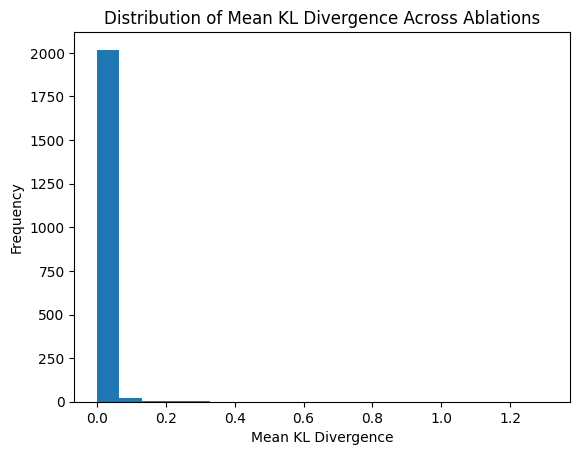

In [ ]:
# histogram of mean_kl
plt.hist(batch_ablation_results["mean_kl"], bins=20)
plt.xlabel("Mean KL Divergence")
plt.ylabel("Frequency")
plt.title("Distribution of Mean KL Divergence Across Ablations")
plt.show()

## Prompt-set batch ablation

In [7]:
!python scripts/batch_ablate.py \
  --checkpoint saved_models/sae_model_4x.pt \
  --eval-texts-path notebooks/files/eval_dates_times.txt \
  --output runs/ablation/dates_times-1.csv

`torch_dtype` is deprecated! Use `dtype` instead!
Loaded pretrained model pythia-70m into HookedTransformer
Ablating features:   4%|▋                | 88/2048 [00:54<19:55,  1.64feature/s]^C
  File "/Users/samswitz/miniforge3/envs/sae/lib/python3.10/site-packages/transformer_lens/hook_points.py", line 447, in run_with_hooks
    return hooked_model.forward(*model_args, **model_kwargs)
  File "/Users/samswitz/miniforge3/envs/sae/lib/python3.10/site-packages/transformer_lens/HookedTransformer.py", line 620, in forward
    residual = block(
  File "/Users/samswitz/miniforge3/envs/sae/lib/python3.10/site-packages/torch/nn/modules/module.py", line 1776, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
  File "/Users/samswitz/miniforge3/envs/sae/lib/python3.10/site-packages/torch/nn/modules/module.py", line 1787, in _call_impl
    return forward_call(*args, **kwargs)
  File "/Users/samswitz/miniforge3/envs/sae/lib/python3.10/site-packages/transformer_lens/components/transform

In [ ]:
!python scripts/batch_ablate.py \
  --checkpoint saved_models/sae_model_4x.pt \
  --eval-texts-path notebooks/files/eval_generic_prose.txt \
  --output runs/ablation/generic_prose-1.csv

In [ ]:
!python scripts/batch_ablate.py \
  --checkpoint saved_models/sae_model_4x.pt \
  --eval-texts-path notebooks/files/eval_geography_news.txt \
  --output runs/ablation/geography_news-1.csv